#### Business Problem

A rapidly expanding retail chain operating across multiple regions has experienced consistent revenue growth over the past three years. However, despite increasing sales, overall profitability has steadily declined.
- conduct a comprehensive business analysis and identify where profitability is being lost.

#### Data Collection & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.chdir("C:\\working_files")
sales_df = pd.read_excel("Retail_revenue_leakage.xlsx" , sheet_name="fact_sales")
stores_df= pd.read_excel("Retail_revenue_leakage.xlsx" , sheet_name="dim_branches")
customer_df= pd.read_excel("Retail_revenue_leakage.xlsx" , sheet_name="dim_customers")
product_df= pd.read_excel("Retail_revenue_leakage.xlsx" , sheet_name="dim_products")
date_df= pd.read_excel("Retail_revenue_leakage.xlsx" , sheet_name="dim_date")


#### sales data

In [3]:
sales_df.head()

,order_line_id,order_id,customer_id,product_id,branch_id,order_date_id,ship_date_id,ship_mode,days_to_ship,quantity,unit_price,discount_pct,sales,cogs,shipping_cost,gross_profit,operating_profit,profit_margin_pct,margin_class
0,OL-00001,ORD-01000,CUST-0305,PRD-0084,BR-08,20241203,20241209.0,Standard Class,6,7,241619.77,0.00,1691338.40,1042416.85,1346.81,648921.55,647574.74,38.37,medium
1,OL-00002,ORD-01001,CUST-0324,PRD-0027,BR-01,20230111,20230114.0,Second Class,3,5,103268.69,0.25,387257.57,270974.61,2221.88,116282.97,114061.08,30.03,medium
2,OL-00003,ORD-01002,CUST-0056,PRD-0009,BR-11,20220425,20220430.0,Second Class,5,4,116366.43,0.18,381681.91,260903.99,1615.83,120777.91,119162.08,31.64,medium
3,OL-00004,ORD-01003,CUST-0459,PRD-0031,BR-06,20220320,20220324.0,Second Class,4,1,14391.66,0.00,14391.66,9718.70,365.92,4672.96,4307.04,32.47,low
4,OL-00005,ORD-01003,CUST-0459,PRD-0070,BR-06,20220320,20220324.0,Second Class,4,6,6211.44,0.00,37268.63,21067.35,2721.16,16201.28,13480.12,43.47,medium


In [4]:
sales_df.columns

Index(['order_line_id', 'order_id', 'customer_id', 'product_id', 'branch_id',
       'order_date_id', 'ship_date_id', 'ship_mode', 'days_to_ship',
       'quantity', 'unit_price', 'discount_pct', 'sales', 'cogs',
       'shipping_cost', 'gross_profit', 'operating_profit',
       'profit_margin_pct', 'margin_class'],
      dtype='object')

In [5]:
sales_df.shape

(10317, 19)

We  have 10317 instances in the dataset  with 19 attributes

In [6]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_line_id      10317 non-null  object 
 1   order_id           10317 non-null  object 
 2   customer_id        10317 non-null  object 
 3   product_id         10317 non-null  object 
 4   branch_id          10317 non-null  object 
 5   order_date_id      10317 non-null  int64  
 6   ship_date_id       10204 non-null  float64
 7   ship_mode          10317 non-null  object 
 8   days_to_ship       10317 non-null  int64  
 9   quantity           10317 non-null  int64  
 10  unit_price         10317 non-null  float64
 11  discount_pct       10317 non-null  float64
 12  sales              10317 non-null  float64
 13  cogs               10317 non-null  float64
 14  shipping_cost      10214 non-null  float64
 15  gross_profit       10317 non-null  float64
 16  operating_profit   103

#### Data Cleaning & Preprocessing

In [7]:
sales_df.isnull().sum()

order_line_id          0
order_id               0
customer_id            0
product_id             0
branch_id              0
order_date_id          0
ship_date_id         113
ship_mode              0
days_to_ship           0
quantity               0
unit_price             0
discount_pct           0
sales                  0
cogs                   0
shipping_cost        103
gross_profit           0
operating_profit       0
profit_margin_pct      0
margin_class           0
dtype: int64

In [8]:
sales_df.isnull().mean()*100

order_line_id        0.000000
order_id             0.000000
customer_id          0.000000
product_id           0.000000
branch_id            0.000000
order_date_id        0.000000
ship_date_id         1.095280
ship_mode            0.000000
days_to_ship         0.000000
quantity             0.000000
unit_price           0.000000
discount_pct         0.000000
sales                0.000000
cogs                 0.000000
shipping_cost        0.998352
gross_profit         0.000000
operating_profit     0.000000
profit_margin_pct    0.000000
margin_class         0.000000
dtype: float64

we have 103 missing data in shipping_cost and 113 ship_date_id. Since these missing values are 1% each we are dropping them

In [9]:
sales_df = sales_df.dropna(subset=["shipping_cost","ship_date_id"])

In [10]:
sales_df.isnull().sum()

order_line_id        0
order_id             0
customer_id          0
product_id           0
branch_id            0
order_date_id        0
ship_date_id         0
ship_mode            0
days_to_ship         0
quantity             0
unit_price           0
discount_pct         0
sales                0
cogs                 0
shipping_cost        0
gross_profit         0
operating_profit     0
profit_margin_pct    0
margin_class         0
dtype: int64

In [11]:
sales_df.shape

(10101, 19)

In [12]:
# Check for duplicates
sales_df.duplicated().sum()

0

We don't have duplicates in the dataset

#### Descriptive statistics

In [13]:
sales_df.describe()

,order_date_id,ship_date_id,days_to_ship,quantity,unit_price,discount_pct,sales,cogs,shipping_cost,gross_profit,operating_profit,profit_margin_pct
count,1.010100e+04,1.010100e+04,10101.000000,10101.000000,10101.000000,10101.000000,1.010100e+04,1.010100e+04,10101.000000,1.010100e+04,1.010100e+04,10101.000000
mean,2.023048e+07,2.023059e+07,4.445203,3.988615,91395.319852,0.095121,3.290606e+05,2.227217e+05,1906.252884,1.063389e+05,1.044326e+05,31.675073
std,8.127572e+03,8.203049e+03,2.504786,1.986033,99862.186458,0.099737,4.329071e+05,3.100736e+05,1880.305739,1.679721e+05,1.677056e+05,20.092035
min,2.022010e+07,2.022010e+07,0.000000,1.000000,4250.450000,0.000000,2.700220e+03,1.725410e+03,192.260000,-5.959694e+05,-6.000736e+05,-64.410000
25%,2.022093e+07,2.022100e+07,2.000000,2.000000,13248.800000,0.000000,4.023254e+04,2.696803e+04,789.070000,8.439470e+03,6.662840e+03,20.400000
50%,2.023062e+07,2.023063e+07,5.000000,4.000000,47439.730000,0.050000,1.393715e+05,9.334647e+04,1391.060000,3.495949e+04,3.321557e+04,34.940000
75%,2.024033e+07,2.024033e+07,6.000000,6.000000,150185.900000,0.150000,4.540506e+05,2.845583e+05,2352.160000,1.378842e+05,1.357723e+05,45.860000
max,2.024123e+07,2.025011e+07,8.000000,7.000000,459951.780000,0.400000,2.985809e+06,2.177638e+06,38183.620000,1.546205e+06,1.544903e+06,64.530000


In [14]:
sales_df.dtypes

order_line_id         object
order_id              object
customer_id           object
product_id            object
branch_id             object
order_date_id          int64
ship_date_id         float64
ship_mode             object
days_to_ship           int64
quantity               int64
unit_price           float64
discount_pct         float64
sales                float64
cogs                 float64
shipping_cost        float64
gross_profit         float64
operating_profit     float64
profit_margin_pct    float64
margin_class          object
dtype: object

#### Check Text Inconsistencies

In [15]:
object_columns = sales_df[['order_line_id','order_id','customer_id', 'product_id', 'branch_id','ship_mode','margin_class']]

In [16]:
for i in object_columns :
    print(object_columns[i].unique())

['OL-00001' 'OL-00002' 'OL-00003' ... 'OL-10315' 'OL-10316' 'OL-10317']
['ORD-01000' 'ORD-01001' 'ORD-01002' ... 'ORD-05197' 'ORD-05198'
 'ORD-05199']
['CUST-0305' 'CUST-0324' 'CUST-0056' 'CUST-0459' 'CUST-0002' 'CUST-0087'
 'CUST-0026' 'CUST-0132' 'CUST-0200' 'CUST-0289' 'CUST-0233' 'CUST-0424'
 'CUST-0430' 'CUST-0414' 'CUST-0500' 'CUST-0272' 'CUST-0008' 'CUST-0147'
 'CUST-0399' 'CUST-0192' 'CUST-0462' 'CUST-0273' 'CUST-0484' 'CUST-0466'
 'CUST-0412' 'CUST-0451' 'CUST-0041' 'CUST-0376' 'CUST-0112' 'CUST-0220'
 'CUST-0207' 'CUST-0260' 'CUST-0420' 'CUST-0315' 'CUST-0184' 'CUST-0138'
 'CUST-0381' 'CUST-0074' 'CUST-0335' 'CUST-0089' 'CUST-0011' 'CUST-0332'
 'CUST-0306' 'CUST-0432' 'CUST-0189' 'CUST-0276' 'CUST-0487' 'CUST-0449'
 'CUST-0082' 'CUST-0275' 'CUST-0377' 'CUST-0226' 'CUST-0341' 'CUST-0277'
 'CUST-0004' 'CUST-0040' 'CUST-0447' 'CUST-0164' 'CUST-0109' 'CUST-0253'
 'CUST-0411' 'CUST-0168' 'CUST-0474' 'CUST-0053' 'CUST-0407' 'CUST-0298'
 'CUST-0152' 'CUST-0314' 'CUST-0423' 'CUST-012

**Reason for the code above** I once built a dashboard in PowerBi that  had a break because of wrong IDs , i dont waant to rebuild dashboard from scratch again.

#### Products Data

In [17]:
product_df.head(2)

,product_id,product_name,category,sub_category
0,PRD-0001,Smartphones - SKU1,Electronics,Smartphones
1,PRD-0002,Smartphones - SKU2,Electronics,Smartphones


In [18]:
product_df.shape

(90, 4)

In [19]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    90 non-null     object
 1   product_name  90 non-null     object
 2   category      90 non-null     object
 3   sub_category  90 non-null     object
dtypes: object(4)
memory usage: 2.9+ KB


#### Data Preprocessing

In [20]:
product_df.isnull().sum()

product_id      0
product_name    0
category        0
sub_category    0
dtype: int64

In [21]:
# Check for duplicates
product_df.duplicated().sum()

0

#### Check Text Inconsistencies

In [22]:
object_columns = product_df[["product_id","category","sub_category"]]

In [23]:
for i in object_columns:
    print(object_columns[i].unique())

['PRD-0001' 'PRD-0002' 'PRD-0003' 'PRD-0004' 'PRD-0005' 'PRD-0006'
 'PRD-0007' 'PRD-0008' 'PRD-0009' 'PRD-0010' 'PRD-0011' 'PRD-0012'
 'PRD-0013' 'PRD-0014' 'PRD-0015' 'PRD-0016' 'PRD-0017' 'PRD-0018'
 'PRD-0019' 'PRD-0020' 'PRD-0021' 'PRD-0022' 'PRD-0023' 'PRD-0024'
 'PRD-0025' 'PRD-0026' 'PRD-0027' 'PRD-0028' 'PRD-0029' 'PRD-0030'
 'PRD-0031' 'PRD-0032' 'PRD-0033' 'PRD-0034' 'PRD-0035' 'PRD-0036'
 'PRD-0037' 'PRD-0038' 'PRD-0039' 'PRD-0040' 'PRD-0041' 'PRD-0042'
 'PRD-0043' 'PRD-0044' 'PRD-0045' 'PRD-0046' 'PRD-0047' 'PRD-0048'
 'PRD-0049' 'PRD-0050' 'PRD-0051' 'PRD-0052' 'PRD-0053' 'PRD-0054'
 'PRD-0055' 'PRD-0056' 'PRD-0057' 'PRD-0058' 'PRD-0059' 'PRD-0060'
 'PRD-0061' 'PRD-0062' 'PRD-0063' 'PRD-0064' 'PRD-0065' 'PRD-0066'
 'PRD-0067' 'PRD-0068' 'PRD-0069' 'PRD-0070' 'PRD-0071' 'PRD-0072'
 'PRD-0073' 'PRD-0074' 'PRD-0075' 'PRD-0076' 'PRD-0077' 'PRD-0078'
 'PRD-0079' 'PRD-0080' 'PRD-0081' 'PRD-0082' 'PRD-0083' 'PRD-0084'
 'PRD-0085' 'PRD-0086' 'PRD-0087' 'PRD-0088' 'PRD-0089' 'PRD-0

#### Customers' Data

In [24]:
customer_df.head(2)

,customer_id,customer_name,segment
0,CUST-0001,Tobi Abubakar,Consumer
1,CUST-0002,Chidi Bello,Consumer


In [25]:
customer_df.shape

(500, 3)

In [26]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    500 non-null    object
 1   customer_name  500 non-null    object
 2   segment        500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB


#### Data Preprocessing

In [27]:
# check for missing values
customer_df.isnull().sum()

customer_id      0
customer_name    0
segment          0
dtype: int64

In [28]:
# Check for duplicates
customer_df.duplicated().sum()

0

#### Check Text Inconsistencies

In [29]:
object_columns =customer_df[["customer_id","segment"]]

In [30]:
for i in object_columns:
    print(object_columns[i].unique())

['CUST-0001' 'CUST-0002' 'CUST-0003' 'CUST-0004' 'CUST-0005' 'CUST-0006'
 'CUST-0007' 'CUST-0008' 'CUST-0009' 'CUST-0010' 'CUST-0011' 'CUST-0012'
 'CUST-0013' 'CUST-0014' 'CUST-0015' 'CUST-0016' 'CUST-0017' 'CUST-0018'
 'CUST-0019' 'CUST-0020' 'CUST-0021' 'CUST-0022' 'CUST-0023' 'CUST-0024'
 'CUST-0025' 'CUST-0026' 'CUST-0027' 'CUST-0028' 'CUST-0029' 'CUST-0030'
 'CUST-0031' 'CUST-0032' 'CUST-0033' 'CUST-0034' 'CUST-0035' 'CUST-0036'
 'CUST-0037' 'CUST-0038' 'CUST-0039' 'CUST-0040' 'CUST-0041' 'CUST-0042'
 'CUST-0043' 'CUST-0044' 'CUST-0045' 'CUST-0046' 'CUST-0047' 'CUST-0048'
 'CUST-0049' 'CUST-0050' 'CUST-0051' 'CUST-0052' 'CUST-0053' 'CUST-0054'
 'CUST-0055' 'CUST-0056' 'CUST-0057' 'CUST-0058' 'CUST-0059' 'CUST-0060'
 'CUST-0061' 'CUST-0062' 'CUST-0063' 'CUST-0064' 'CUST-0065' 'CUST-0066'
 'CUST-0067' 'CUST-0068' 'CUST-0069' 'CUST-0070' 'CUST-0071' 'CUST-0072'
 'CUST-0073' 'CUST-0074' 'CUST-0075' 'CUST-0076' 'CUST-0077' 'CUST-0078'
 'CUST-0079' 'CUST-0080' 'CUST-0081' 'CUST-0082' 'C

#### store dataset

In [31]:
stores_df.head()

,branch_id,branch_name,region
0,BR-01,Aba,South
1,BR-02,Abeokuta,West
2,BR-03,Enugu Main,East
3,BR-04,Ibadan North,West
4,BR-05,Ikeja,North


In [32]:
stores_df.shape

(12, 3)

The company has 12 branhes 

In [33]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   branch_id    12 non-null     object
 1   branch_name  12 non-null     object
 2   region       12 non-null     object
dtypes: object(3)
memory usage: 420.0+ bytes


In [34]:
# check for missing values
stores_df.isnull().sum()

branch_id      0
branch_name    0
region         0
dtype: int64

In [35]:
# Check for duplicates
stores_df.duplicated().sum()

0

#### Check for Text Inconsistencies

In [36]:
for i in stores_df:
    print(stores_df[i].unique())

['BR-01' 'BR-02' 'BR-03' 'BR-04' 'BR-05' 'BR-06' 'BR-07' 'BR-08' 'BR-09'
 'BR-10' 'BR-11' 'BR-12']
['Aba' 'Abeokuta' 'Enugu Main' 'Ibadan North' 'Ikeja' 'Ilorin'
 'Lagos Island' 'Nnewi' 'Onitsha' 'Port Harcourt Central' 'Warri' 'Yaba']
['South' 'West' 'East' 'North']


#### Date Data

In [37]:
date_df.head()

,order_date_id,date,year,quarter,month,month_name,day_of_week
0,20220101,2022-01-01,2022,Q1,1,January,Saturday
1,20220102,2022-01-02,2022,Q1,1,January,Sunday
2,20220103,2022-01-03,2022,Q1,1,January,Monday
3,20220104,2022-01-04,2022,Q1,1,January,Tuesday
4,20220105,2022-01-05,2022,Q1,1,January,Wednesday


In [38]:
date_df.dtypes

order_date_id             int64
date             datetime64[ns]
year                      int64
quarter                  object
month                     int64
month_name               object
day_of_week              object
dtype: object

The `date` column is in datetime dtype, it needs to be converted to date only

#### Date Feature Engineering
TThe `date` needs to be normalized because it contains time in it.

In [39]:
date_df['date'] = pd.to_datetime(date_df['date']).dt.normalize()

In [40]:
print(date_df['date'].dtype)
print(date_df['date'].isna().sum())
print(date_df['date'].duplicated().sum())

datetime64[ns]
0
0


In [41]:
# The 1st day transaction was made
date_df['date'].min()

Timestamp('2022-01-01 00:00:00')

In [42]:
# The last day transaction was made
date_df['date'].max()

Timestamp('2025-01-06 00:00:00')

**check for missing dates within the date range**

In [43]:
# Create the complete date range
all_dates = pd.date_range(
    start=date_df['date'].min(),
    end=date_df['date'].max(),
    freq='D'
)

# Find dates that are missing
missing_dates = all_dates.difference(date_df['date'])

print(f"Number of missing dates: {len(missing_dates)}")
missing_dates

Number of missing dates: 1


DatetimeIndex(['2024-03-26'], dtype='datetime64[ns]', freq='D')

`2024-03-26` is missing in the `date_df`, this is because the date from Fact-sales table was used to create all the columns in date_df and on 2024-03-26, there was no saales. If we use it like this we will get blank or -- in KPI Card when doing Time base analysis in PowerBi

#### Creating a new Date Table

In [44]:
Date_df = pd.DataFrame({
    'date': pd.date_range(
        start=date_df['date'].min(),
        end=date_df['date'].max(),
        freq='D'
    )
})

In [45]:
Date_df.head()

,date
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05


In [46]:
# Create the same key /ID format as Fact_Sales (YYYYMMDD)
Date_df['order_date_id'] = ( Date_df['date'].dt.strftime('%Y%m%d').astype(int))

# Other date attributes
Date_df['year'] = Date_df['date'].dt.year
Date_df['quarter'] = 'Q' + Date_df['date'].dt.quarter.astype(str)
Date_df['month'] = Date_df['date'].dt.month
Date_df['month_name'] = Date_df['date'].dt.strftime('%B')
Date_df['day_of_week'] = Date_df['date'].dt.strftime('%A')

# Optional: Put the key first
Date_df = Date_df[['order_date_id', 'date', 'year', 'quarter', 'month', 'month_name', 'day_of_week']]

In [47]:
Date_df.head()

,order_date_id,date,year,quarter,month,month_name,day_of_week
0,20220101,2022-01-01,2022,Q1,1,January,Saturday
1,20220102,2022-01-02,2022,Q1,1,January,Sunday
2,20220103,2022-01-03,2022,Q1,1,January,Monday
3,20220104,2022-01-04,2022,Q1,1,January,Tuesday
4,20220105,2022-01-05,2022,Q1,1,January,Wednesday


**Check if there is missing date in the newly created Date_df Table**

In [48]:
# Create the complete date range
all_dates = pd.date_range(
    start=Date_df['date'].min(),
    end=Date_df['date'].max(),
    freq='D'
)

# Find dates that are missing
missing_dates = all_dates.difference(Date_df['date'])

print(f"Number of missing dates: {len(missing_dates)}")
missing_dates

Number of missing dates: 0


DatetimeIndex([], dtype='datetime64[ns]', freq='D')

#### Merge all dataset to a single dataframe for analysis

In [49]:
sales_product = sales_df.merge(product_df, on='product_id')
sales_product_customers = sales_product.merge(customer_df, on= 'customer_id') 
sales_product_customers_stores = sales_product_customers.merge(stores_df , on = 'branch_id')
full_dataset = sales_product_customers_stores.merge(Date_df , on = 'order_date_id')
                                                   

In [50]:
full_dataset.head()

,order_line_id,order_id,customer_id,product_id,branch_id,order_date_id,ship_date_id,ship_mode,days_to_ship,quantity,...,customer_name,segment,branch_name,region,date,year,quarter,month,month_name,day_of_week
0,OL-00001,ORD-01000,CUST-0305,PRD-0084,BR-08,20241203,20241209.0,Standard Class,6,7,...,Taiwo Nwachukwu,Small Business,Nnewi,East,2024-12-03,2024,Q4,12,December,Tuesday
1,OL-00002,ORD-01001,CUST-0324,PRD-0027,BR-01,20230111,20230114.0,Second Class,3,5,...,Chioma Abubakar,Corporate,Aba,South,2023-01-11,2023,Q1,1,January,Wednesday
2,OL-00003,ORD-01002,CUST-0056,PRD-0009,BR-11,20220425,20220430.0,Second Class,5,4,...,Ikenna Okonkwo,Consumer,Warri,South,2022-04-25,2022,Q2,4,April,Monday
3,OL-00004,ORD-01003,CUST-0459,PRD-0031,BR-06,20220320,20220324.0,Second Class,4,1,...,Bola Olawale,Small Business,Ilorin,West,2022-03-20,2022,Q1,3,March,Sunday
4,OL-00005,ORD-01003,CUST-0459,PRD-0070,BR-06,20220320,20220324.0,Second Class,4,6,...,Bola Olawale,Small Business,Ilorin,West,2022-03-20,2022,Q1,3,March,Sunday


In [51]:
full_dataset.columns

Index(['order_line_id', 'order_id', 'customer_id', 'product_id', 'branch_id',
       'order_date_id', 'ship_date_id', 'ship_mode', 'days_to_ship',
       'quantity', 'unit_price', 'discount_pct', 'sales', 'cogs',
       'shipping_cost', 'gross_profit', 'operating_profit',
       'profit_margin_pct', 'margin_class', 'product_name', 'category',
       'sub_category', 'customer_name', 'segment', 'branch_name', 'region',
       'date', 'year', 'quarter', 'month', 'month_name', 'day_of_week'],
      dtype='object')

#### Exploratory Data Analysis
Lets explore the data to uncover insights

In [52]:
numeric_cols = full_dataset.select_dtypes( include =["number"])

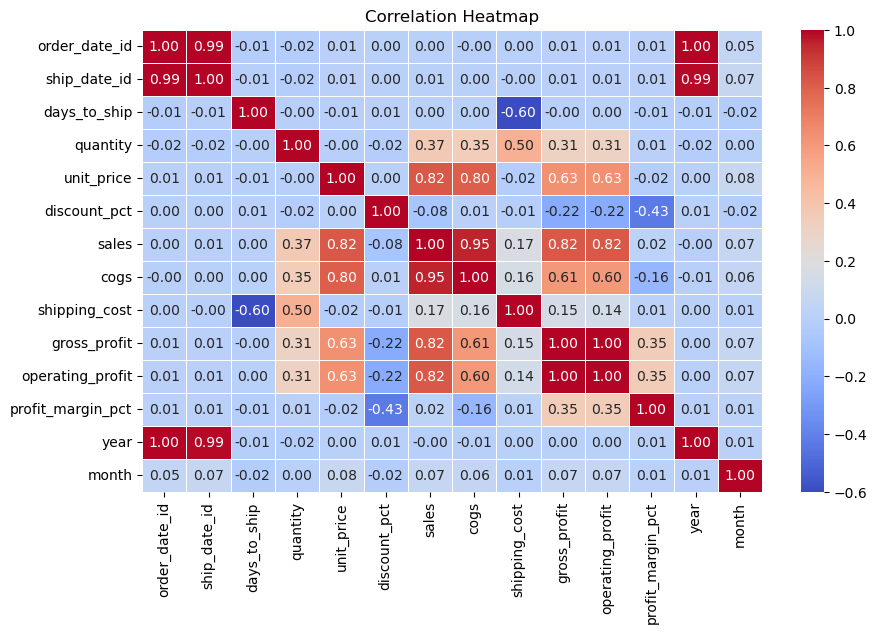

In [53]:
corr_matrix = numeric_cols.corr()
# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f',linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Revenue Analysis

**Revenue by region**

In [54]:
revenue_region = full_dataset.groupby('region')['sales'].sum().sort_values(ascending=False)
revenue_region

region
East     8.470269e+08
West     8.443605e+08
South    8.294821e+08
North    8.029714e+08
Name: sales, dtype: float64

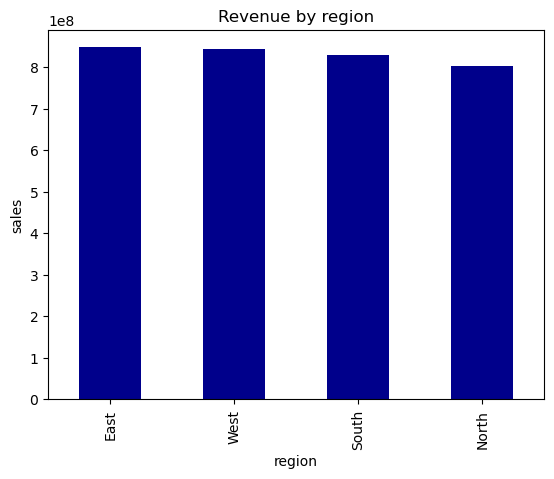

In [55]:
revenue_region.plot(kind='bar',color='darkblue')
plt.title('Revenue by region')
plt.ylabel('sales')
plt.show()

**Revenue by store_branch**

In [56]:
revenue_branch = full_dataset.groupby('branch_name')['sales'].sum().sort_values(ascending=False).head()
revenue_branch

branch_name
Yaba                     2.949510e+08
Onitsha                  2.947368e+08
Ilorin                   2.907760e+08
Port Harcourt Central    2.880478e+08
Ibadan North             2.811042e+08
Name: sales, dtype: float64

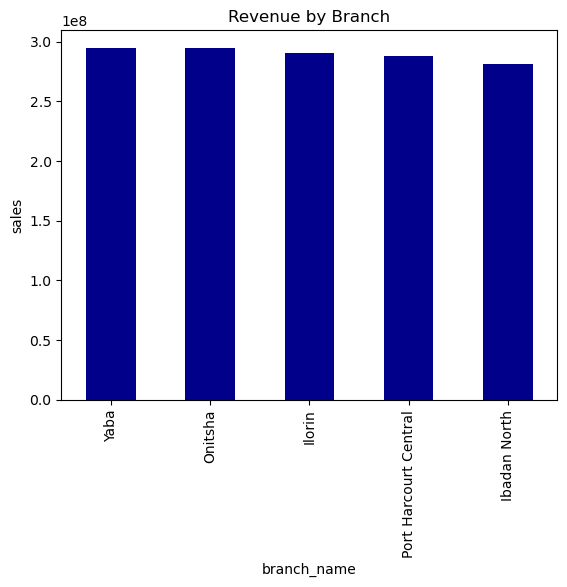

In [57]:
revenue_branch.plot(kind='bar',color='darkblue')
plt.title('Revenue by Branch')
plt.ylabel('sales')
plt.show()

**Revenue by customer segment**

In [58]:
rev_seg= full_dataset.groupby('segment')['sales'].sum().sort_values(ascending=False).head()
rev_seg

segment
Consumer          1.502012e+09
Corporate         1.052747e+09
Small Business    5.925633e+08
Government        1.765184e+08
Name: sales, dtype: float64

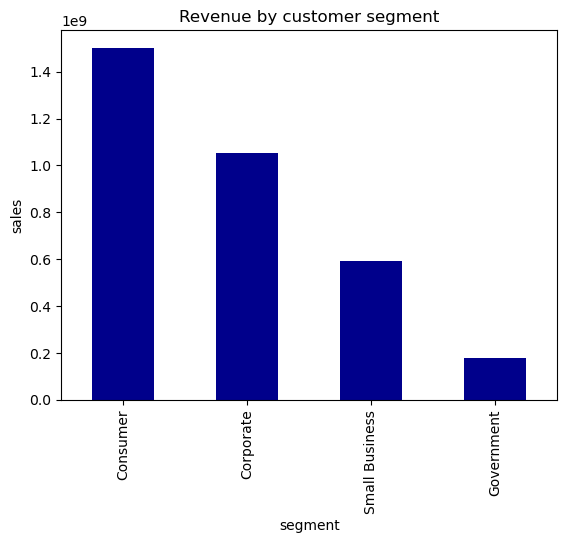

In [59]:
rev_seg.plot(kind='bar',color='darkblue')
plt.title('Revenue by customer segment')
plt.ylabel('sales')
plt.show()

The **consumer** segment generated more revenue

**Revenue by product category**

In [60]:
rev_prod= full_dataset.groupby('category')['sales'].sum().sort_values(ascending=False).head()
rev_prod

category
Sports & Leisure    7.668227e+08
Health & Beauty     6.036662e+08
FMCG                5.919809e+08
Fashion             5.455911e+08
Electronics         4.709517e+08
Name: sales, dtype: float64

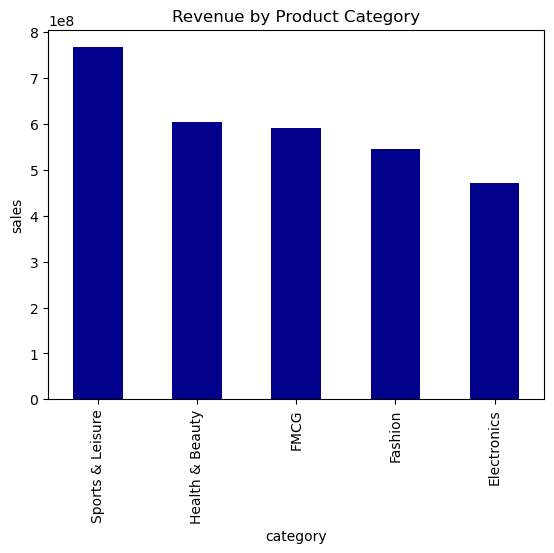

In [61]:
rev_prod.plot(kind='bar',color='darkblue')
plt.title('Revenue by Product Category')
plt.ylabel('sales')
plt.show()

**Sport & Leisure** generated more sales than other products

#### Profitability Analysis

In [62]:
full_dataset.columns

Index(['order_line_id', 'order_id', 'customer_id', 'product_id', 'branch_id',
       'order_date_id', 'ship_date_id', 'ship_mode', 'days_to_ship',
       'quantity', 'unit_price', 'discount_pct', 'sales', 'cogs',
       'shipping_cost', 'gross_profit', 'operating_profit',
       'profit_margin_pct', 'margin_class', 'product_name', 'category',
       'sub_category', 'customer_name', 'segment', 'branch_name', 'region',
       'date', 'year', 'quarter', 'month', 'month_name', 'day_of_week'],
      dtype='object')

**Gross Profit**

In [63]:
full_dataset['gross_profit'].sum()

1074129246.0300002

#### Profit by category

In [82]:
category_prof = full_dataset.groupby('category')['profit_margin_pct'].mean().sort_values()
category_prof

category
Electronics         25.342825
Sports & Leisure    28.902237
Health & Beauty     30.022398
Home & Living       31.546177
FMCG                35.887620
Fashion             38.080042
Name: profit_margin_pct, dtype: float64

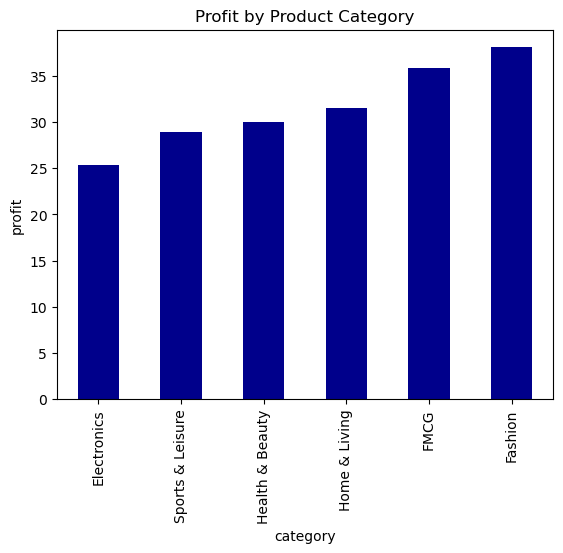

In [83]:
category_prof.plot(kind='bar',color='darkblue')
plt.title('Profit by Product Category')
plt.ylabel('profit')
plt.show()

#### Profits By products category

In [65]:
# Top 7 products with most profits
top_products = full_dataset.groupby('sub_category')['operating_profit'].sum().sort_values(ascending=False).head(7)
top_products

sub_category
Bicycles              1.092981e+08
Outdoor Gear          8.440160e+07
Baby Products         7.893670e+07
Footwear              7.497595e+07
Women's Clothing      7.373868e+07
Kitchen Appliances    7.056014e+07
Personal Care         5.242244e+07
Name: operating_profit, dtype: float64

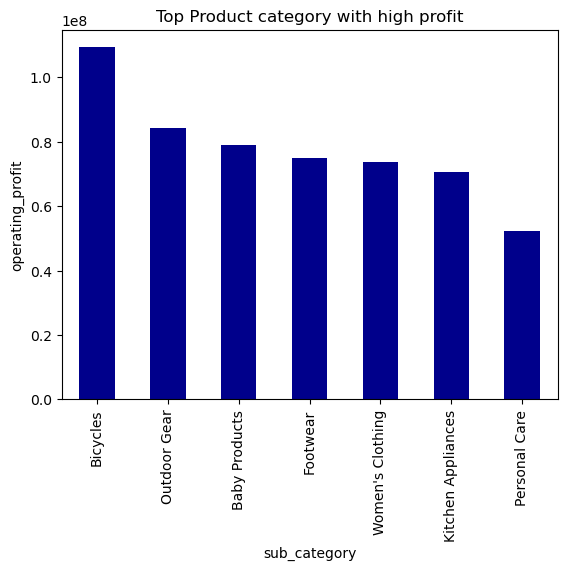

In [66]:
top_products.plot(kind='bar',color='darkblue')
plt.title('Top Product category with high profit')
plt.ylabel('operating_profit')
plt.show()

#### Top 7 Products with small profits

In [67]:
under_performing_products = full_dataset.groupby('sub_category')['operating_profit'].sum().sort_values(ascending=False).tail(7)
under_performing_products

sub_category
Accessories      15805636.60
Snacks           11865768.46
Bedding          10909356.37
Smartphones      10752744.79
Smartwatches      9640608.51
Gym Equipment     4393498.99
Furniture         2017200.41
Name: operating_profit, dtype: float64

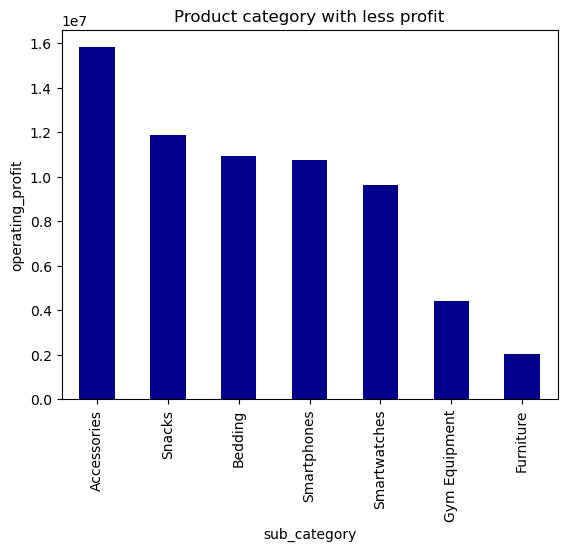

In [68]:
under_performing_products.plot(kind='bar',color='darkblue')
plt.title('Product category with less profit')
plt.ylabel('operating_profit')
plt.show()

#### Profit by store branch

In [69]:
full_dataset.groupby('branch_name')['operating_profit'].sum().sort_values(ascending=False)

branch_name
Nnewi                    95749487.52
Onitsha                  94278992.39
Yaba                     93355605.28
Ilorin                   92718613.74
Abeokuta                 90220054.64
Ibadan North             89071505.75
Enugu Main               88567548.84
Port Harcourt Central    85877996.33
Lagos Island             83584490.96
Warri                    82748863.98
Aba                      82375184.75
Ikeja                    76325842.27
Name: operating_profit, dtype: float64

#### Profit by customer segment

In [70]:
segment_profit = full_dataset.groupby('segment')['operating_profit'].sum()
segment_profit

segment
Consumer          4.767793e+08
Corporate         3.283652e+08
Government        5.671034e+07
Small Business    1.930194e+08
Name: operating_profit, dtype: float64

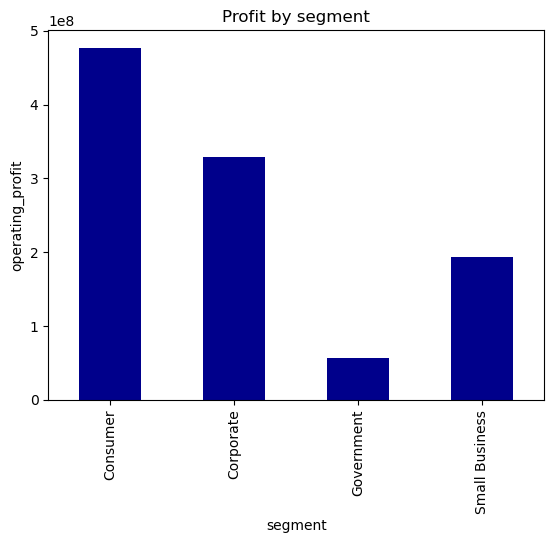

In [71]:
segment_profit.plot(kind='bar',color='darkblue')
plt.title('Profit by segment')
plt.ylabel('operating_profit')
plt.show()

#### Profit By shipping Mode

In [72]:
ShippingMode_profit = full_dataset.groupby('ship_mode')['operating_profit'].sum()
ShippingMode_profit

ship_mode
First Class       1.520432e+08
Same Day          1.071152e+08
Second Class      2.822115e+08
Standard Class    5.135042e+08
Name: operating_profit, dtype: float64

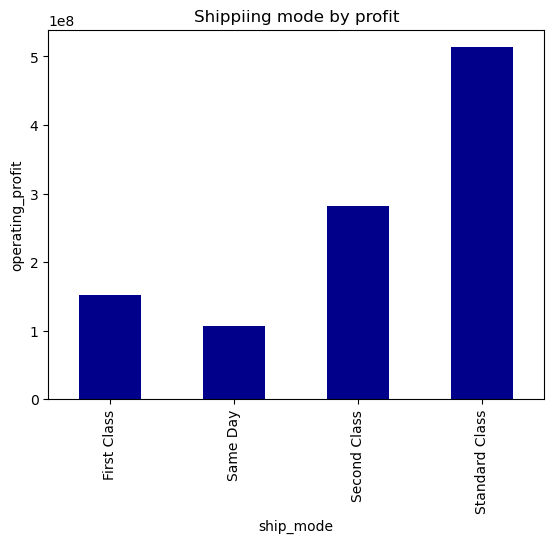

In [84]:
ShippingMode_profit.plot(kind='bar',color='darkblue')
plt.title('Shippiing mode by profit')
plt.ylabel('operating_profit')
plt.show()

**Observation** : The standard shipping mode generated more Profit. For more profit the business owner should stick with `second class`, and `standard class` shipping mode

### Discount Analysis

In [74]:
full_dataset.columns

Index(['order_line_id', 'order_id', 'customer_id', 'product_id', 'branch_id',
       'order_date_id', 'ship_date_id', 'ship_mode', 'days_to_ship',
       'quantity', 'unit_price', 'discount_pct', 'sales', 'cogs',
       'shipping_cost', 'gross_profit', 'operating_profit',
       'profit_margin_pct', 'margin_class', 'product_name', 'category',
       'sub_category', 'customer_name', 'segment', 'branch_name', 'region',
       'date', 'year', 'quarter', 'month', 'month_name', 'day_of_week'],
      dtype='object')

**Average discount of product category**

In [75]:
full_dataset.groupby('category')['discount_pct'].mean()*100

category
Electronics         11.681928
FMCG                 9.128702
Fashion              9.084675
Health & Beauty      9.211990
Home & Living        8.923900
Sports & Leisure     9.080796
Name: discount_pct, dtype: float64

The average discount for **Electronics** product is higher than others and is not the product category with more sales

#### Discount impact on profit

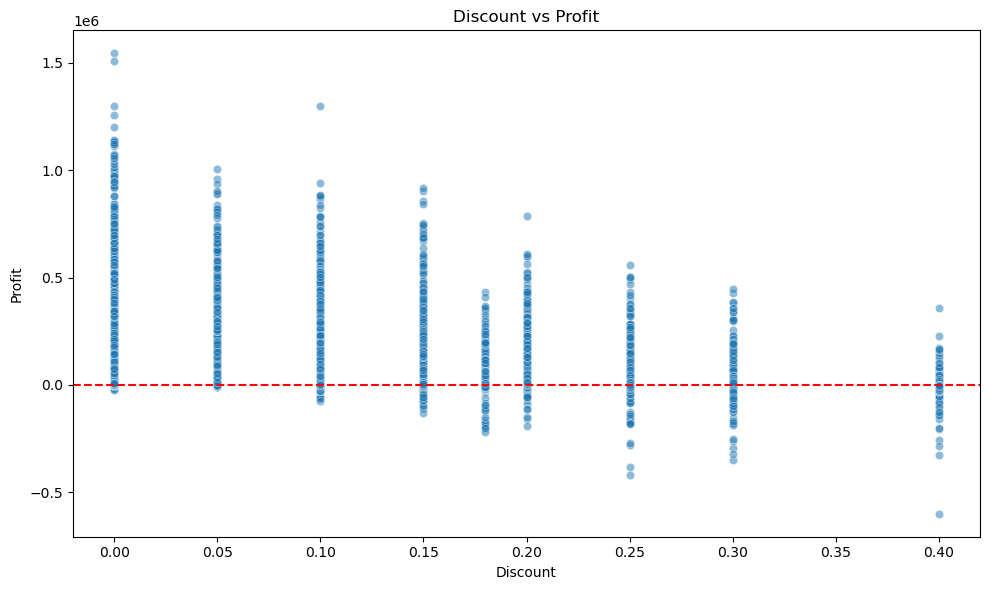

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

sns.scatterplot(data=full_dataset, x="discount_pct", y="operating_profit", alpha=0.5)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

#### Observation
- The discount and profit relationship is negatively linear. Profits started declining with increase in discount
- 15% discounts above recorded more losses

#### Transfering the Cleaned Datasets to SQL Server Management studio(SSMS) for Analysis

In [77]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [78]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


**Connection code(Window Authentification)**

In [79]:
server = ".\\SQLEXPRESS"  # SQL Server instance in my SQL Server management studio
database = "Retail_db"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect={}".format(
        quote_plus(connection_string)
    )
)
print("Connection created successfully!")

Connection created successfully!


In [74]:
# UPLOAD YOUR DATAFRAME TO SSMS
sales_df.to_sql(
    name="Fact_sales",
    con=engine,
    if_exists="replace",
    index=False
)

print("Fact_sales data uploaded successfully!")

Fact_sales data uploaded successfully!


In [75]:
product_df.to_sql(
    name="Product",
    con=engine,
    if_exists="replace",
    index=False
)

print("Product data uploaded successfully!")

Product data uploaded successfully!


In [76]:
stores_df.to_sql(
    name="Branch",
    con=engine,
    if_exists="replace",
    index=False
)

print("Store branch uploaded successfully!")

Store branch uploaded successfully!


In [77]:
customer_df.to_sql(
    name="Customers",
    con=engine,
    if_exists="replace",
    index=False
)

print("Customer data uploaded successfully!")

Customer data uploaded successfully!


In [80]:
Date_df.to_sql(
    name="Date",
    con=engine,
    if_exists="replace",
    index=False
)

print("Date data uploaded successfully!")

C:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Date data uploaded successfully!
